In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import platform

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)

df = pd.read_csv('data/accepted.csv')
df2 = df.copy()

C:\Users\gywns\AppData\Local\Temp\ipykernel_13716\2435735676.py:20: DtypeWarning: Columns (0: id, 1: desc, 2: next_pymnt_d, 3: verification_status_joint, 4: sec_app_earliest_cr_line, 5: hardship_type, 6: hardship_reason, 7: hardship_status, 8: hardship_start_date, 9: hardship_end_date, 10: payment_plan_start_date, 11: hardship_loan_status, 12: debt_settlement_flag_date, 13: settlement_status, 14: settlement_date) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/accepted.csv')


In [2]:
df2.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(1), str(37)
memory usage: 2.5+ GB


In [4]:
col = ['hardship_flag',
'hardship_type',
'hardship_reason',
'hardship_status',
'hardship_amount',
'hardship_start_date',
'hardship_end_date',
'hardship_length',
'hardship_dpd',
'hardship_loan_status',
'hardship_payoff_balance_amount',
'hardship_last_payment_amount',
'deferral_term',
'orig_projected_additional_accrued_interest',
'payment_plan_start_date',
'debt_settlement_flag',
'debt_settlement_flag_date',
'settlement_status',
'settlement_date',
'settlement_amount',
'settlement_percentage',
'settlement_term'
]

df2[col].isnull().sum()

hardship_flag                                      33
hardship_type                                 2249784
hardship_reason                               2249784
hardship_status                               2249784
hardship_amount                               2249784
hardship_start_date                           2249784
hardship_end_date                             2249784
hardship_length                               2249784
hardship_dpd                                  2249784
hardship_loan_status                          2249784
hardship_payoff_balance_amount                2249784
hardship_last_payment_amount                  2249784
deferral_term                                 2249784
orig_projected_additional_accrued_interest    2252050
payment_plan_start_date                       2249784
debt_settlement_flag                               33
debt_settlement_flag_date                     2226455
settlement_status                             2226455
settlement_date             

In [5]:
df2[col].isnull().mean() * 100

hardship_flag                                  0.001460
hardship_type                                 99.517097
hardship_reason                               99.517097
hardship_status                               99.517097
hardship_amount                               99.517097
hardship_start_date                           99.517097
hardship_end_date                             99.517097
hardship_length                               99.517097
hardship_dpd                                  99.517097
hardship_loan_status                          99.517097
hardship_payoff_balance_amount                99.517097
hardship_last_payment_amount                  99.517097
deferral_term                                 99.517097
orig_projected_additional_accrued_interest    99.617331
payment_plan_start_date                       99.517097
debt_settlement_flag                           0.001460
debt_settlement_flag_date                     98.485160
settlement_status                             98

In [6]:
df2['hardship_flag'].value_counts()

hardship_flag
N    2259836
Y        832
Name: count, dtype: int64

In [7]:
df2['debt_settlement_flag'].value_counts()

debt_settlement_flag
N    2226422
Y      34246
Name: count, dtype: int64

In [8]:
col2 = ['out_prncp',
'out_prncp_inv',
'total_pymnt',
'total_pymnt_inv',
'total_rec_prncp',
'total_rec_int',
'total_rec_late_fee',
'last_pymnt_d',
'last_pymnt_amnt',
'next_pymnt_d',
'last_credit_pull_d',
'last_fico_range_high',
'last_fico_range_low',
'recoveries',
'collection_recovery_fee',
'disbursement_method'
]

df2[col2].isnull().sum()

out_prncp                       33
out_prncp_inv                   33
total_pymnt                     33
total_pymnt_inv                 33
total_rec_prncp                 33
total_rec_int                   33
total_rec_late_fee              33
last_pymnt_d                  2460
last_pymnt_amnt                 33
next_pymnt_d               1345343
last_credit_pull_d             105
last_fico_range_high            33
last_fico_range_low             33
recoveries                      33
collection_recovery_fee         33
disbursement_method             33
dtype: int64

In [9]:
df2[col2].isnull().mean() * 100

out_prncp                   0.001460
out_prncp_inv               0.001460
total_pymnt                 0.001460
total_pymnt_inv             0.001460
total_rec_prncp             0.001460
total_rec_int               0.001460
total_rec_late_fee          0.001460
last_pymnt_d                0.108816
last_pymnt_amnt             0.001460
next_pymnt_d               59.509993
last_credit_pull_d          0.004645
last_fico_range_high        0.001460
last_fico_range_low         0.001460
recoveries                  0.001460
collection_recovery_fee     0.001460
disbursement_method         0.001460
dtype: float64

In [10]:
df2['hardship_flag'].value_counts()

hardship_flag
N    2259836
Y        832
Name: count, dtype: int64

In [11]:
df2['debt_settlement_flag'].value_counts()

debt_settlement_flag
N    2226422
Y      34246
Name: count, dtype: int64

In [12]:
df2['hardship_type'].value_counts()

hardship_type
INTEREST ONLY-3 MONTHS DEFERRAL    10917
Name: count, dtype: int64

In [13]:
df2['loan_status'].value_counts()

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

In [14]:
df3 = df2[df2['loan_status'].isin(['Fully Paid', 'Charged Off'])]
df3['loan_repaid'] = df3['loan_status'].map({'Fully Paid': 1, 'Charged Off': 0})

# 1. 수치형 컬럼만 선택
numeric_df = df3.select_dtypes(include=['float64', 'int64'])

# 2. loan_repaid와 다른 변수들 간의 상관관계 계산
correlations = numeric_df.corr()['loan_repaid'].sort_values(ascending=False)

# 3. 결과 확인 (상위 10개, 하위 10개)
print("--- 상환 성공(1)과 상관관계가 가장 높은 변수들 ---")
print(correlations.head(10)) # 자기 자신(loan_repaid) 포함

print("\n--- 상환 실패(0)와 상관관계가 가장 높은 변수들 ---")
print(correlations.tail(10))

--- 상환 성공(1)과 상관관계가 가장 높은 변수들 ---
loan_repaid                            1.000000
last_fico_range_high                   0.667842
last_fico_range_low                    0.575706
total_rec_prncp                        0.438944
last_pymnt_amnt                        0.347385
total_pymnt                            0.315180
total_pymnt_inv                        0.314751
sec_app_fico_range_low                 0.251242
sec_app_fico_range_high                0.251242
sec_app_mths_since_last_major_derog    0.159333
Name: loan_repaid, dtype: float64

--- 상환 실패(0)와 상관관계가 가장 높은 변수들 ---
hardship_dpd              -0.244754
int_rate                  -0.258792
collection_recovery_fee   -0.480216
recoveries                -0.505415
member_id                       NaN
out_prncp                       NaN
out_prncp_inv                   NaN
policy_code                     NaN
deferral_term                   NaN
hardship_length                 NaN
Name: loan_repaid, dtype: float64


In [15]:
status_mapping = {
        'Fully Paid': 1,
        'Does not meet the credit policy. Status:Fully Paid': 1,    
    'Charged Off': 0,
    'Does not meet the credit policy. Status:Charged Off': 0
}

df4 = df2[df2['loan_status'].isin(status_mapping.keys())].copy()
df4['loan_repaid'] = df4['loan_status'].map(status_mapping)

# 1. 수치형 컬럼만 선택
numeric_df = df4.select_dtypes(include=['float64', 'int64'])

# 2. loan_repaid와 다른 변수들 간의 상관관계 계산
correlations = numeric_df.corr()['loan_repaid'].sort_values(ascending=False)


# 3. 결과 확인 (상위 10개, 하위 10개)
print("--- 상환 성공(1)과 상관관계가 가장 높은 변수들 ---")
print(correlations.head(10)) # 자기 자신(loan_repaid) 포함

print("\n--- 상환 실패(0)와 상관관계가 가장 높은 변수들 ---")
print(correlations.tail(10))

# default는 사실상 charged off와 거의 동일하게 간주한다. -> 돈을 못 갚을 사람을 최대한 다 찾아내는 것이라면 포함시키는 것이 통계적으로 더 풍부한 데이터를 제공

--- 상환 성공(1)과 상관관계가 가장 높은 변수들 ---
loan_repaid                            1.000000
last_fico_range_high                   0.667138
last_fico_range_low                    0.575054
total_rec_prncp                        0.438911
last_pymnt_amnt                        0.347230
total_pymnt                            0.315290
total_pymnt_inv                        0.314767
sec_app_fico_range_low                 0.251242
sec_app_fico_range_high                0.251242
sec_app_mths_since_last_major_derog    0.159333
Name: loan_repaid, dtype: float64

--- 상환 실패(0)와 상관관계가 가장 높은 변수들 ---
hardship_dpd              -0.244754
int_rate                  -0.258563
collection_recovery_fee   -0.479106
recoveries                -0.504771
member_id                       NaN
out_prncp                       NaN
out_prncp_inv                   NaN
policy_code                     NaN
deferral_term                   NaN
hardship_length                 NaN
Name: loan_repaid, dtype: float64


# 1. "데이터 누수(Data Leakage)" 주의보: 삭제해야 할 변수들
가장 의외이거나 혹은 주의해야 할 부분입니다. 상관관계 상위에 있는 아래 변수들은 대출이 실행된 '후'에 상환 과정에서 발생하는 데이터입니다.

total_rec_prncp (회수된 원금), total_pymnt (총 상환액), last_pymnt_amnt (마지막 상환액): * 당연히 돈을 잘 갚은 사람은 이 수치들이 높겠죠? 하지만 우리는 **대출 승인 시점(돈을 빌려주기 전)**에 이 사람이 갚을지 말지를 예측해야 합니다.

빌려주기도 전에 "이 사람이 나중에 원금을 얼마나 낼까?"를 미리 알 수는 없으므로, 이 변수들은 모델 학습에서 반드시 제외해야 합니다.

recoveries (채권 회수액), collection_recovery_fee (추심 수수료):

이 변수들은 '부도가 난 후'에 돈을 받아내기 위해 발생하는 비용입니다. 상환 실패(0)와 관계가 매우 깊게 나오지만, 이 역시 결과론적인 데이터입니다.

# 2. 아주 잘 찾아낸 "진짜" 예측 변수
반면, 아래 변수들은 대출 승인 시점에도 알 수 있는 정보이며 상환 가능성을 아주 잘 설명해 줍니다.

last_fico_range_high / low (신용 점수): * 상관계수가 0.5~0.6으로 매우 높죠? 역시 신용도가 가장 강력한 지표임을 통계적으로 증명하신 겁니다.

팁: last_fico는 대출 기간 중 변동된 점수일 수 있으니, 대출 시점의 점수인 fico_range_low/high와도 비교해 보세요.

int_rate (이자율): * -0.25 정도로 음의 상관관계가 명확하네요. 이자율이 높을수록(고위험 대출일수록) 못 갚을 확률이 높다는 금융의 기본 원리가 잘 나타나 있습니다.

sec_app_fico_range (공동 신청인 신용 점수): * 공동 신청인이 있는 경우 그들의 신용도도 유의미한 영향을 준다는 점이 흥미롭네요.

# 3. NaN 변수들에 대한 처방
member_id, out_prncp, policy_code 등이 NaN인 이유는 다음과 같습니다.

policy_code: 모든 값이 '1'이라서 변동성이 없기 때문일 확률이 높습니다. (분석 가치 없음)

out_prncp (잔액): 상환이 완료(Fully Paid)되거나 부도(Charged Off)가 난 데이터만 필터링하셨기 때문에, 현재 남은 잔액은 모두 0이라서 NaN이 떴을 겁니다.

결론: 이 변수들은 과감히 drop 하셔도 됩니다.

# 4. 정리 및 다음 단계 제안
지금 분석하신 결과는 "결과 데이터"와 "예측 데이터"가 섞여 있는 상태입니다.

예측 모델용 변수 선별: total_rec_..., recoveries, last_pymnt_... 등 결과론적 변수를 제외하고 다시 상관관계를 뽑아보세요.

새로운 강자 등장: 이 변수들을 지우고 나면 dti(부채 비율), revol_util(카드 사용률), annual_inc(연봉) 같은 변수들이 상위권으로 올라올 겁니다. 그게 진짜 우리가 찾아야 할 **'상환 예측 요인'**입니다.

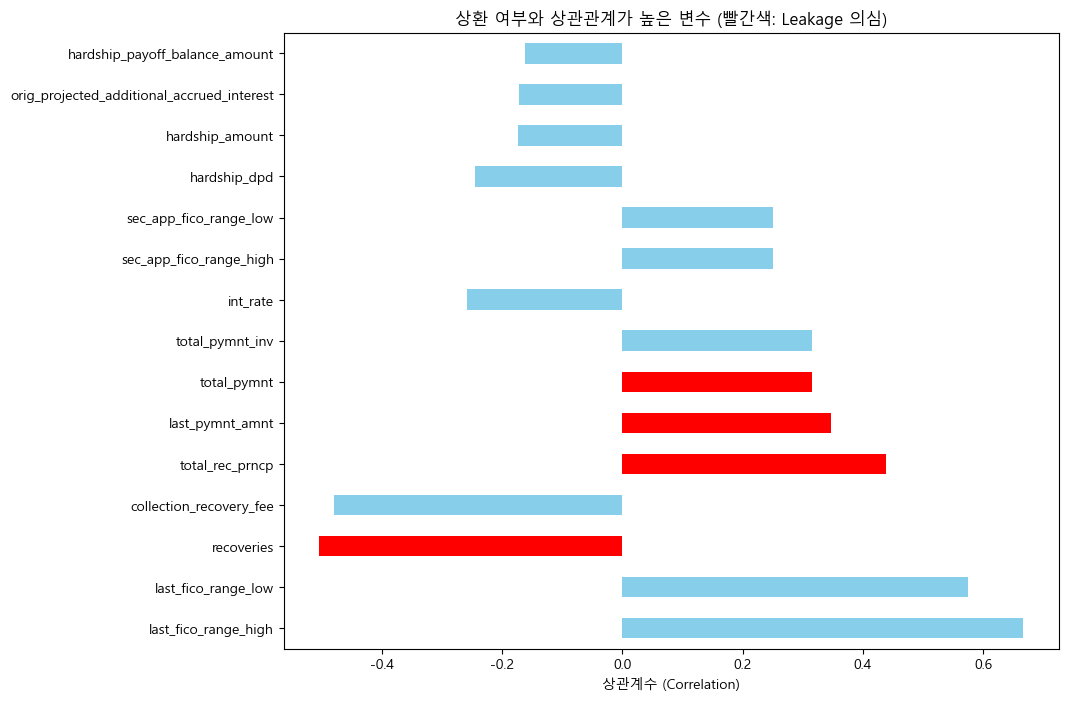

In [16]:
# import platform

# # 운영체제별 한글 폰트 설정
# if platform.system() == 'Windows':
#     plt.rcParams['font.family'] = 'Malgun Gothic'
# elif platform.system() == 'Darwin':  # macOS
#     plt.rcParams['font.family'] = 'AppleGothic'
# else:  # Linux
#     plt.rcParams['font.family'] = 'NanumGothic'

# # 마이너스 기호 깨짐 방지
# plt.rcParams['axes.unicode_minus'] = False

# 1. 상관계수 상위/하위 추출 (절대값 기준 상위 15개 추천)
top_corr = correlations.abs().sort_values(ascending=False).head(16).drop('loan_repaid')
top_corr_raw = correlations[top_corr.index] # 원래 부호(+/-) 반영

# 2. 시각화
plt.figure(figsize=(10, 8))
colors = ['red' if x in ['total_rec_prncp', 'last_pymnt_amnt', 'recoveries', 'total_pymnt'] else 'skyblue' for x in top_corr_raw.index]
top_corr_raw.plot(kind='barh', color=colors)
plt.title('상환 여부와 상관관계가 높은 변수 (빨간색: Leakage 의심)')
plt.xlabel('상관계수 (Correlation)')
plt.show()

빨간색으로 표시된 부분은 과적합 위험이 있어서 제외해야함.
- total_pymnt : 총 상환액
- last_pymnt_amnt : 마지막 상환액
- total_rec_prncp : 총 회수 원금
- recoveries : 채권 회수액

In [17]:
# 1. 제외할 변수 리스트 (결과론적 변수 + 식별자 + 무의미한 변수)
leakage_cols = [
    'total_rec_prncp', 'total_pymnt', 'total_pymnt_inv', 'last_pymnt_amnt', 
    'recoveries', 'collection_recovery_fee', 'total_rec_int', 'total_rec_late_fee',
    'last_fico_range_high', 'last_fico_range_low',  # 상환 중 변동된 신용점수이므로 제외
    'id', 'member_id', 'url', 'desc', 'policy_code' # 식별 및 무의미 변수
]

# 2. 제외 리스트에 포함되지 않은 수치형 컬럼만 선택
# 현재 df4에 담긴 컬럼 중 leakage_cols를 제외한 것만 필터링합니다.
predictive_cols = [col for col in df4.select_dtypes(include=['float64', 'int64']).columns 
                   if col not in leakage_cols]

# 3. 상관관계 계산 및 정렬
# loan_repaid는 타겟이므로 포함해서 계산합니다.
predictive_corr = df4[predictive_cols].corr()['loan_repaid'].dropna().sort_values()

# 4. 결과 확인
print("--- [상환 실패] 위험을 높이는 '진짜' 예측 변수 TOP 10 ---")
print(predictive_corr.head(10))

print("\n" + "="*50 + "\n")

print("--- [상환 성공] 가능성을 높이는 '진짜' 예측 변수 TOP 10 ---")
# 자기 자신(loan_repaid)을 제외하고 출력
print(predictive_corr.drop('loan_repaid').tail(10).sort_values(ascending=False))

--- [상환 실패] 위험을 높이는 '진짜' 예측 변수 TOP 10 ---
int_rate                                     -0.258563
hardship_dpd                                 -0.244754
hardship_amount                              -0.173362
orig_projected_additional_accrued_interest   -0.172316
hardship_payoff_balance_amount               -0.162574
sec_app_inq_last_6mths                       -0.150850
sec_app_revol_util                           -0.141919
dti_joint                                    -0.140860
sec_app_collections_12_mths_ex_med           -0.107618
acc_open_past_24mths                         -0.099869
Name: loan_repaid, dtype: float64


--- [상환 성공] 가능성을 높이는 '진짜' 예측 변수 TOP 10 ---
sec_app_fico_range_low                 0.251242
sec_app_fico_range_high                0.251242
sec_app_mths_since_last_major_derog    0.159333
sec_app_mort_acc                       0.141606
fico_range_low                         0.130725
fico_range_high                        0.130724
annual_inc_joint                       0.

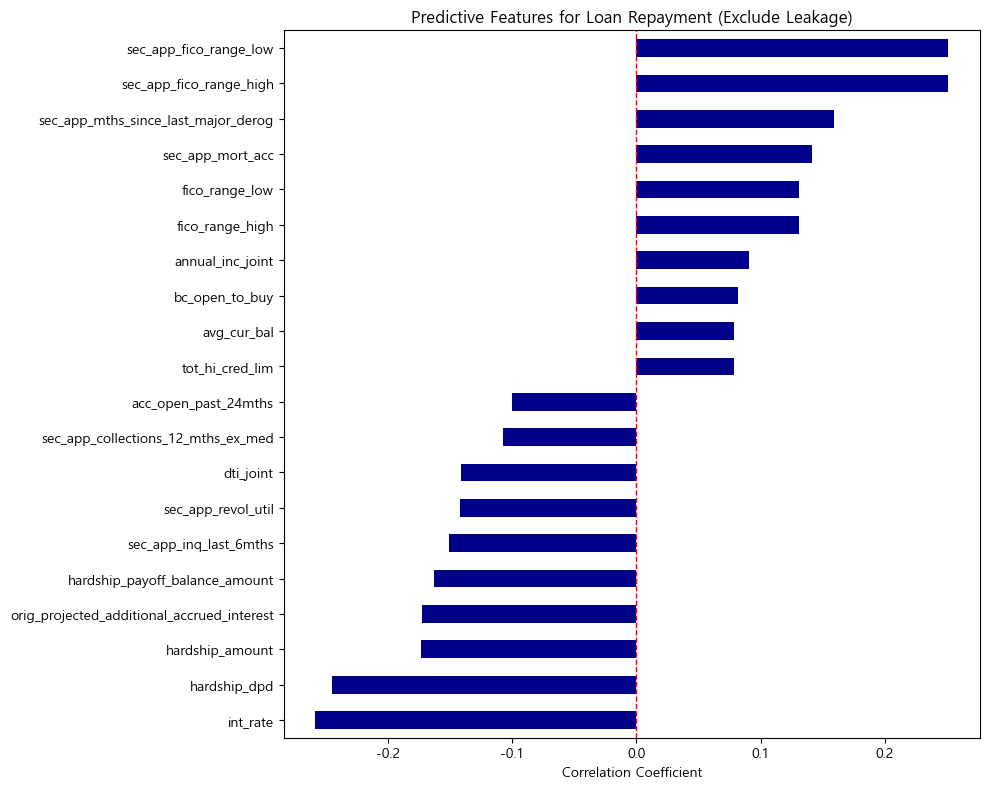

In [18]:
plt.figure(figsize=(10, 8))
# 상위/하위 핵심 변수들만 모아서 시각화
top_bottom_features = pd.concat([predictive_corr.head(10), predictive_corr.drop('loan_repaid').tail(10)])
top_bottom_features.plot(kind='barh', color='darkblue')

plt.title('Predictive Features for Loan Repayment (Exclude Leakage)')
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

In [19]:
df4['application_type'].value_counts()

application_type
Individual    1322259
Joint App       25800
Name: count, dtype: int64

In [20]:
df2['loan_status'].value_counts()

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

In [21]:
# 등급별 실제 상환 성공률 확인
grade_analysis = df4.groupby('grade')['loan_repaid'].mean()
print(grade_analysis)

grade
A    0.939585
B    0.866053
C    0.775586
D    0.696242
E    0.615728
F    0.548553
G    0.503324
Name: loan_repaid, dtype: float64


C:\Users\gywns\AppData\Local\Temp\ipykernel_13716\3793767276.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=grade_analysis.index, y=grade_analysis.values, palette=colors[::-1])


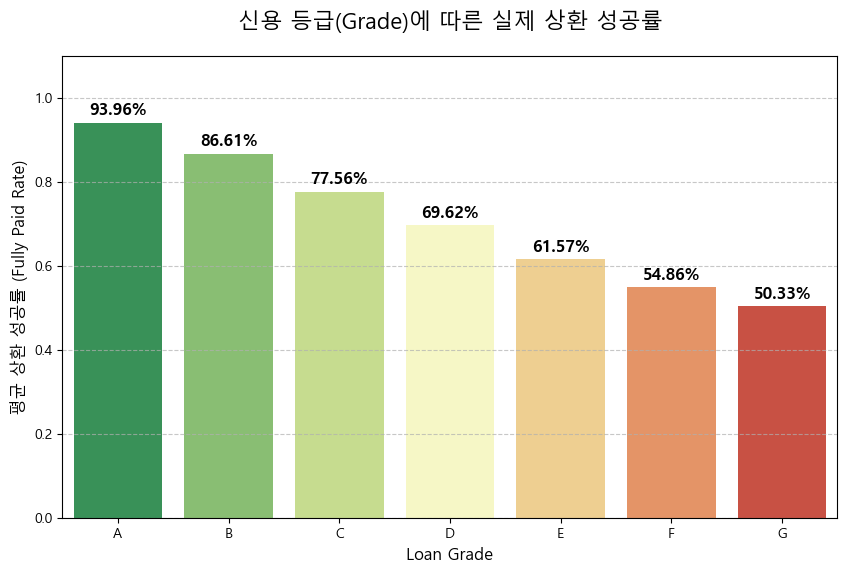

In [22]:
# 데이터 준비 (A~G 순서로 정렬)
grade_analysis = df4.groupby('grade')['loan_repaid'].mean().sort_index()

# 시각화 설정
plt.figure(figsize=(10, 6))
colors = sns.color_palette("RdYlGn", len(grade_analysis)) # 초록(우량) -> 빨강(위험)

# 막대 그래프 그리기
barplot = sns.barplot(x=grade_analysis.index, y=grade_analysis.values, palette=colors[::-1])

# 수치 표시 (막대 위에 % 표시)
for i, v in enumerate(grade_analysis.values):
    plt.text(i, v + 0.01, f'{v:.2%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('신용 등급(Grade)에 따른 실제 상환 성공률', fontsize=16, pad=20)
plt.ylabel('평균 상환 성공률 (Fully Paid Rate)', fontsize=12)
plt.xlabel('Loan Grade', fontsize=12)
plt.ylim(0, 1.1) # 여유 공간 확보
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

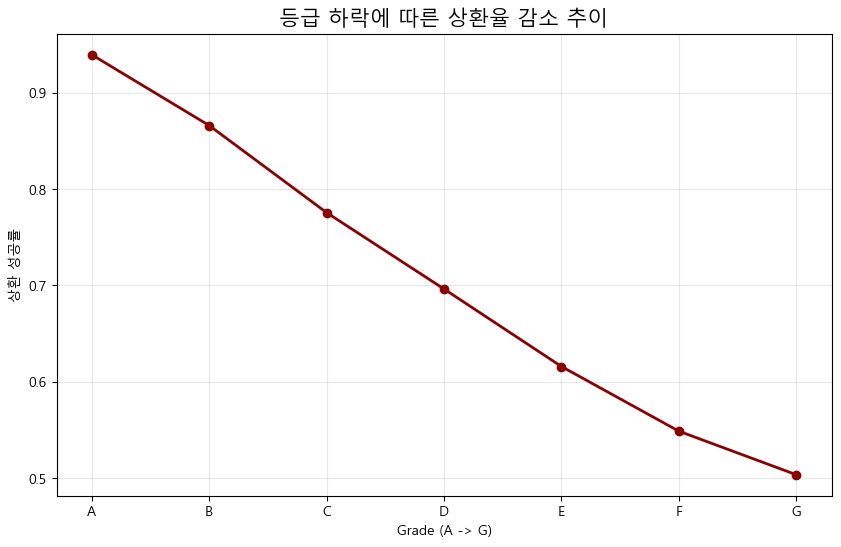

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(grade_analysis.index, grade_analysis.values, marker='o', linestyle='-', color='darkred', linewidth=2)

plt.title('등급 하락에 따른 상환율 감소 추이', fontsize=15)
plt.ylabel('상환 성공률')
plt.xlabel('Grade (A -> G)')
plt.grid(True, alpha=0.3)
plt.show()

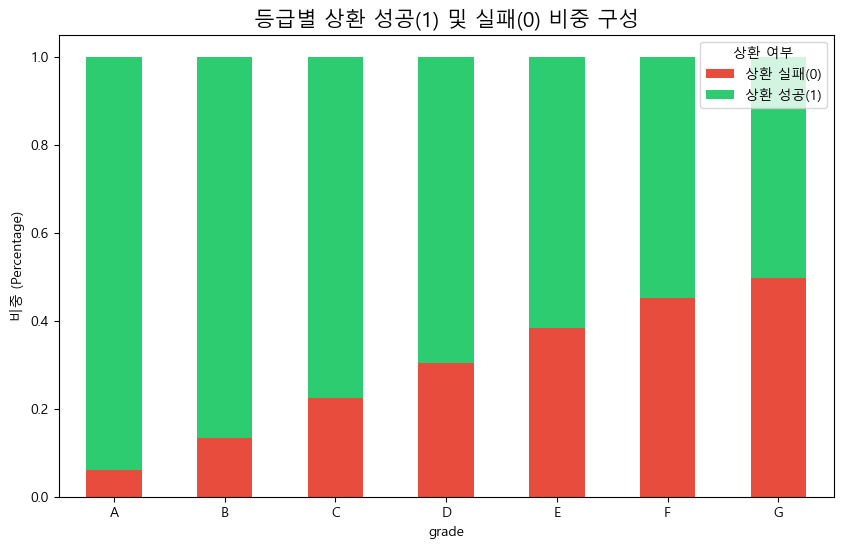

In [24]:
# 등급별 상환 성공(1)과 실패(0)의 빈도를 구한 뒤 비율로 변환
grade_counts = pd.crosstab(df4['grade'], df4['loan_repaid'], normalize='index')

# 시각화
grade_counts.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#e74c3c', '#2ecc71'])

plt.title('등급별 상환 성공(1) 및 실패(0) 비중 구성', fontsize=15)
plt.legend(title="상환 여부", labels=["상환 실패(0)", "상환 성공(1)"], loc='upper right')
plt.ylabel('비중 (Percentage)')
plt.xticks(rotation=0)
plt.show()

C:\Users\gywns\AppData\Local\Temp\ipykernel_13716\1788091944.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='grade', y='int_rate', data=df4, order=grade_order, palette='coolwarm')
C:\Users\gywns\AppData\Local\Temp\ipykernel_13716\1788091944.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='grade', y='annual_inc', data=df4, order=grade_order, palette='viridis', showfliers=False)


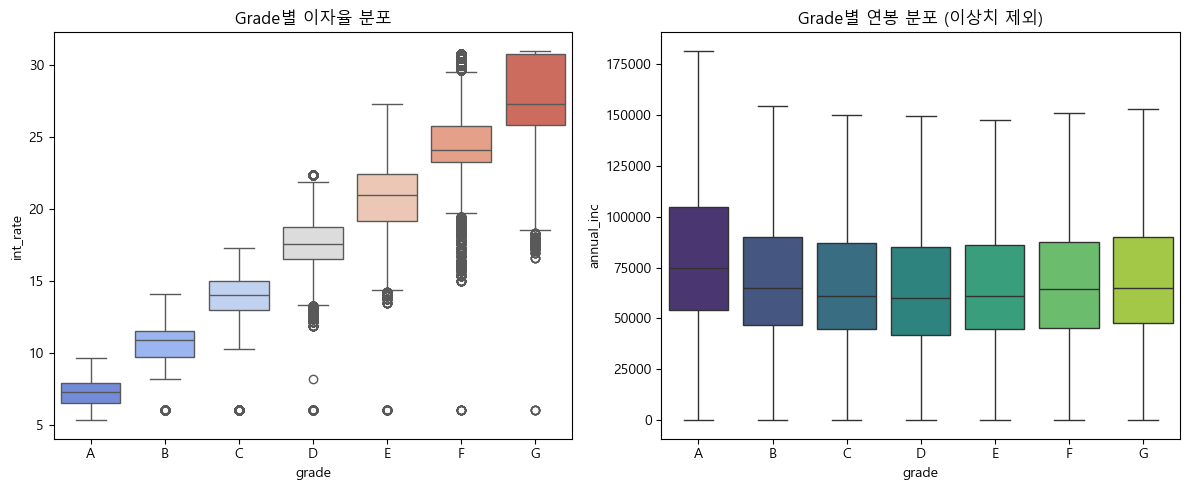

In [25]:
# 시각화를 위한 등급 순서 정의
grade_order = sorted(df4['grade'].unique())

# 1. Grade vs 이자율 (Boxplot)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='grade', y='int_rate', data=df4, order=grade_order, palette='coolwarm')
plt.title('Grade별 이자율 분포')

# 2. Grade vs 연봉 (Boxplot) 
# 연봉은 이상치가 매우 많으므로 showfliers=False를 사용하여 전체적인 흐름을 봅니다.
plt.subplot(1, 2, 2)
sns.boxplot(x='grade', y='annual_inc', data=df4, order=grade_order, palette='viridis', showfliers=False)
plt.title('Grade별 연봉 분포 (이상치 제외)')

plt.tight_layout()
plt.show()

In [26]:
# grade를 숫자로 변환 (A=1, B=2 ... G=7)
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df4['grade_num'] = df4['grade'].map(grade_map)

# 상관계수 확인
multi_corr = df4[['grade_num', 'int_rate', 'annual_inc']].corr(method='spearman')
print("--- 주요 변수 간 상관계수 ---")
print(multi_corr)

--- 주요 변수 간 상관계수 ---
            grade_num  int_rate  annual_inc
grade_num    1.000000  0.956127    -0.12225
int_rate     0.956127  1.000000    -0.12859
annual_inc  -0.122250 -0.128590     1.00000


In [27]:
df4['term_num'] = df4['term'].str.replace(' months', '').astype(int)

# 확인해보기
print(df4[['term', 'term_num']].head())

         term  term_num
0   36 months        36
1   36 months        36
2   60 months        60
4   60 months        60
5   36 months        36


C:\Users\gywns\AppData\Local\Temp\ipykernel_13716\2741142151.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=term_repay.index, y=term_repay.values, palette='coolwarm')


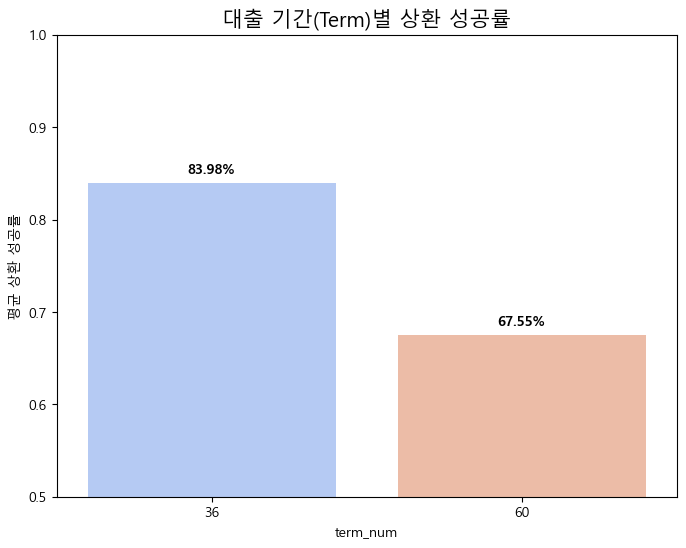

In [28]:
# 기간별 상환율 계산
term_repay = df4.groupby('term_num')['loan_repaid'].mean().sort_index()

plt.figure(figsize=(8, 6))
sns.barplot(x=term_repay.index, y=term_repay.values, palette='coolwarm')

# 수치 표시
for i, v in enumerate(term_repay.values):
    plt.text(i, v + 0.01, f'{v:.2%}', ha='center', fontweight='bold')

plt.title('대출 기간(Term)별 상환 성공률', fontsize=15)
plt.ylabel('평균 상환 성공률')
plt.ylim(0.5, 1.0) # 차이를 명확히 보기 위해 범위 조정
plt.show()

C:\Users\gywns\AppData\Local\Temp\ipykernel_13716\284766678.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=term_stats.index, y=term_stats['int_rate'], ax=ax1, palette='Reds', alpha=0.6)


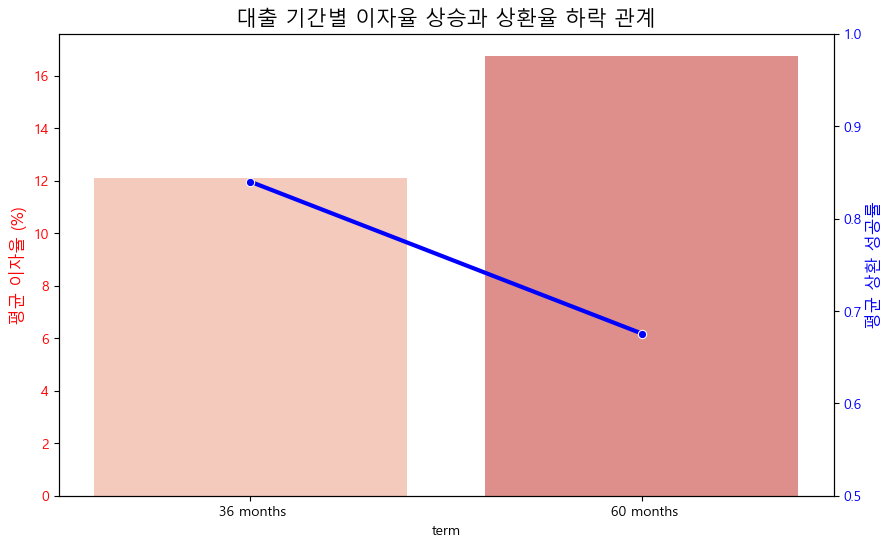

In [29]:
# 기간별 평균 이자율과 상환율 계산
term_stats = df4.groupby('term').agg({
    'int_rate': 'mean',
    'loan_repaid': 'mean'
}).sort_index()

fig, ax1 = plt.subplots(figsize=(10, 6))

# 첫 번째 축: 이자율 (Bar Chart)
sns.barplot(x=term_stats.index, y=term_stats['int_rate'], ax=ax1, palette='Reds', alpha=0.6)
ax1.set_ylabel('평균 이자율 (%)', color='red', fontsize=12)
ax1.tick_params(axis='y', labelcolor='red')

# 두 번째 축: 상환 성공률 (Line Chart)
ax2 = ax1.twinx()
sns.lineplot(x=range(len(term_stats)), y=term_stats['loan_repaid'], ax=ax2, marker='o', color='blue', linewidth=3)
ax2.set_ylabel('평균 상환 성공률', color='blue', fontsize=12)
ax2.tick_params(axis='y', labelcolor='blue')
ax2.set_ylim(0.5, 1.0) # 상환율 변화를 강조하기 위해 범위 조정

plt.title('대출 기간별 이자율 상승과 상환율 하락 관계', fontsize=15)
plt.show()

60개월 대출의 상환 성공률이 36개월보다 눈에 띄게 낮게 나타납니다. 이는 장기 대출일수록 미래의 불확실성이 크고 이자 총액이 많기 때문입니다.

C:\Users\gywns\AppData\Local\Temp\ipykernel_13716\194266146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=home_repay.index, y=home_repay.values, palette='viridis')


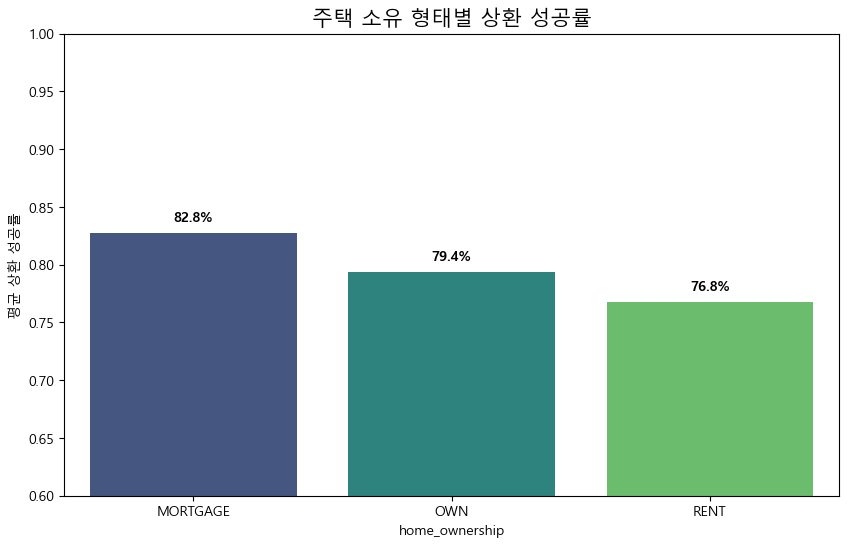

In [30]:
# 주택 소유 형태별 상환율 계산 (데이터가 적은 ANY, NONE 등은 제외하는 것이 좋습니다)
main_home = df4[df4['home_ownership'].isin(['MORTGAGE', 'RENT', 'OWN'])]
home_repay = main_home.groupby('home_ownership')['loan_repaid'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=home_repay.index, y=home_repay.values, palette='viridis')

# 수치 표시
for i, v in enumerate(home_repay.values):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

plt.title('주택 소유 형태별 상환 성공률', fontsize=15)
plt.ylabel('평균 상환 성공률')
plt.ylim(0.6, 1.0)
plt.show()

일반적으로 MORTGAGE나 OWN인 경우가 RENT인 경우보다 상환율이 높게 나오는 경향이 있습니다. 주거가 안정적일수록 금융 신뢰도가 높다는 가설을 검증할 수 있습니다.

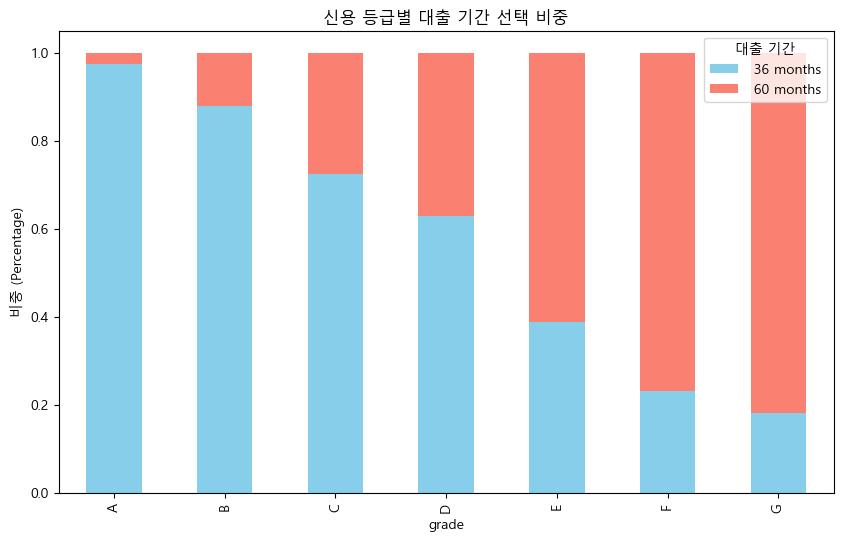

C:\Users\gywns\AppData\Local\Temp\ipykernel_13716\2040157862.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='term', y='loan_amnt', data=df4, palette='Set2')


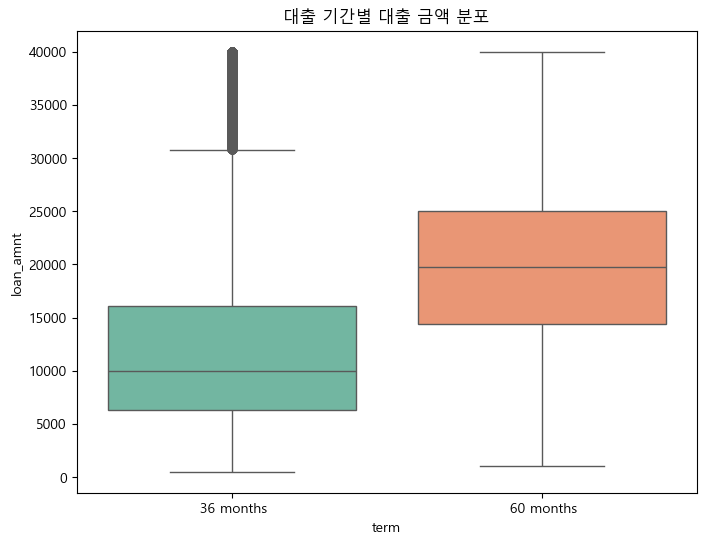

In [31]:
# 1. 등급별(Grade) 대출 기간 선택 비중 확인
term_by_grade = pd.crosstab(df4['grade'], df4['term'], normalize='index')

# 시각화: 등급이 낮아질수록(A->G) 60개월 비중이 늘어나는지 확인
term_by_grade.plot(kind='bar', stacked=True, figsize=(10, 6), color=['skyblue', 'salmon'])
plt.title('신용 등급별 대출 기간 선택 비중')
plt.ylabel('비중 (Percentage)')
plt.legend(title='대출 기간')
plt.show()

# 2. 대출 기간별 평균 대출 금액(loan_amnt) 비교
plt.figure(figsize=(8, 6))
sns.boxplot(x='term', y='loan_amnt', data=df4, palette='Set2')
plt.title('대출 기간별 대출 금액 분포')
plt.show()

G등급으로 갈수록 60개월 대출 비중이 급격히 높아짐
또한 60개월 대출 평균 금액이 36개월 금액보다 높다고 볼 수 있음
- 긴 대출 기간 → 높은 이자율 → 상환 부담 증가 → 낮은 상환율로 이어지는 인과관계

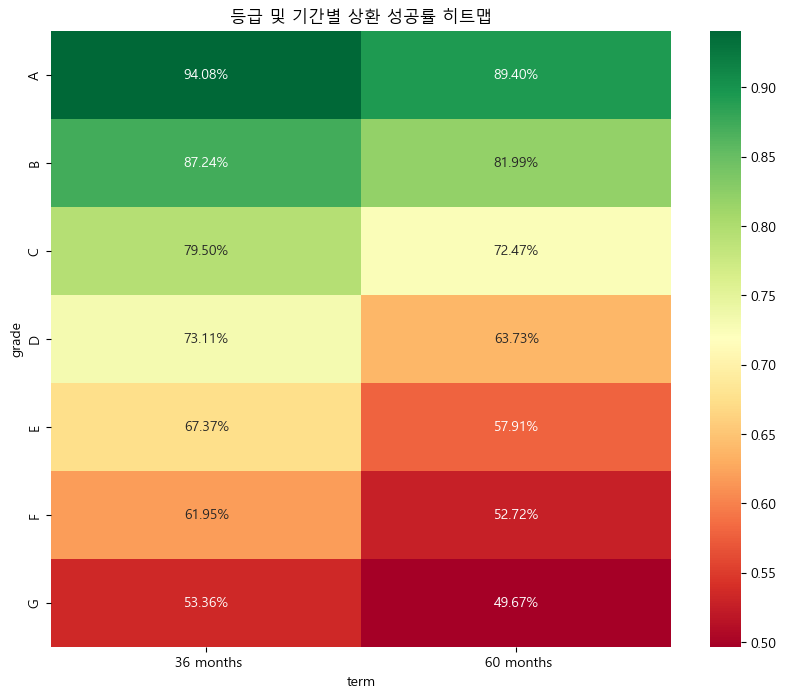

In [32]:
# 등급과 기간을 동시에 고려한 상환율 히트맵
pivot_table = df4.pivot_table(values='loan_repaid', index='grade', columns='term', aggfunc='mean')

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, fmt=".2%", cmap='RdYlGn')
plt.title('등급 및 기간별 상환 성공률 히트맵')
plt.show()

특성 차이: "60개월 대출자는 주로 낮은 신용 등급(Grade)과 높은 대출 금액을 가진 고위험군입니다."

상환 영향: "히트맵을 보면, 같은 C등급이라도 36개월 대출자보다 60개월 대출자의 상환율이 눈에 띄게 낮습니다. 이는 장기 대출 시 발생하는 높은 누적 이자 부담이 실질적인 부도 원인이 됨을 시사합니다."

결론: "따라서 term 변수는 단순히 기간의 의미를 넘어, 대출자의 절박함이나 자금 구조를 간접적으로 나타내는 강력한 예측 변수(Feature)입니다."

In [33]:
from scipy import stats

# 1. 데이터 준비: 36개월과 60개월 그룹의 대출 금액 추출
# 문자열에 '36'이 포함된 행과 '60'이 포함된 행을 각각 분리합니다.
loan_36 = df4[df4['term'].str.contains('36')]['loan_amnt']
loan_60 = df4[df4['term'].str.contains('60')]['loan_amnt']

# 2. 독립표본 T-검정 수행 (Welch's T-test)
t_stat, p_value = stats.ttest_ind(loan_36, loan_60, equal_var=False)

# 3. 결과 출력
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# 4. 유의수준 0.05 기준으로 판정
if p_value < 0.05:
    print("결과: p-value가 0.05보다 작으므로 귀무가설을 기각합니다.")
    print("해석: 두 그룹 간의 평균 대출 금액 차이는 통계적으로 매우 유의미합니다.")
else:
    print("결과: p-value가 0.05보다 크므로 귀무가설을 채택합니다.")
    print("해석: 두 그룹 간의 평균 대출 금액 차이는 통계적으로 유의미하지 않습니다.")

T-statistic: -492.4186
P-value: 0.0000
결과: p-value가 0.05보다 작으므로 귀무가설을 기각합니다.
해석: 두 그룹 간의 평균 대출 금액 차이는 통계적으로 매우 유의미합니다.


In [34]:
# 1. 'Fully Paid' (loan_repaid == 1) 인 데이터만 먼저 필터링
df_success = df4[df4['loan_repaid'] == 1]

# 2. 성공한 그룹 내에서 36개월과 60개월 대출 금액 분리
loan_36_success = df_success[df_success['term'].str.contains('36')]['loan_amnt']
loan_60_success = df_success[df_success['term'].str.contains('60')]['loan_amnt']

# 3. 독립표본 T-검정 수행 (Welch's T-test)
t_stat, p_value = stats.ttest_ind(loan_36_success, loan_60_success, equal_var=False)

print(f"--- [상환 성공자 대상] 기간별 대출 금액 T-검정 ---")

print(f"P-value: {p_value:.4f}")

--- [상환 성공자 대상] 기간별 대출 금액 T-검정 ---
P-value: 0.0000


In [35]:
df4['application_type'].value_counts()

application_type
Individual    1322259
Joint App       25800
Name: count, dtype: int64

In [36]:
cond1 = df4['application_type'] == 'Joint App'
cond2 = df4['annual_inc_joint'].notna()
df4[cond1 & cond2]

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,loan_repaid,grade_num,term_num
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,N,NaN,NaN,NaN,NaN,NaN,NaN,1,2,60
438,68340637,NaN,15000.0,15000.0,15000.0,36 months,11.99,498.15,C,C1,...,N,NaN,NaN,NaN,NaN,NaN,NaN,1,3,36
509,68338594,NaN,24000.0,24000.0,24000.0,60 months,23.13,678.37,F,F2,...,N,NaN,NaN,NaN,NaN,NaN,NaN,1,6,60
529,68340478,NaN,24000.0,24000.0,24000.0,60 months,13.44,551.50,C,C3,...,N,NaN,NaN,NaN,NaN,NaN,NaN,1,3,60
664,68586213,NaN,8750.0,8750.0,8750.0,36 months,18.99,320.70,E,E1,...,N,NaN,NaN,NaN,NaN,NaN,NaN,0,5,36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260439,90075704,NaN,16000.0,16000.0,15925.0,36 months,13.49,542.89,C,C2,...,N,NaN,NaN,NaN,NaN,NaN,NaN,0,3,36
2260609,89052159,NaN,36750.0,36750.0,36750.0,60 months,10.99,798.86,B,B4,...,N,NaN,NaN,NaN,NaN,NaN,NaN,1,2,60
2260613,90236496,NaN,25000.0,25000.0,25000.0,60 months,14.49,588.08,C,C4,...,N,NaN,NaN,NaN,NaN,NaN,NaN,1,3,60
2260626,90091610,NaN,35000.0,35000.0,35000.0,60 months,15.59,843.53,C,C5,...,N,NaN,NaN,NaN,NaN,NaN,NaN,1,3,60


In [37]:
df4['annual_inc_joint'].isnull().sum()

np.int64(1322259)

In [38]:
df4[['application_type', 'annual_inc_joint', 'dti_joint']]

,application_type,annual_inc_joint,dti_joint
0,Individual,NaN,NaN
1,Individual,NaN,NaN
2,Joint App,71000.0,13.85
4,Individual,NaN,NaN
5,Individual,NaN,NaN
...,...,...,...
2260688,Individual,NaN,NaN
2260690,Individual,NaN,NaN
2260691,Individual,NaN,NaN
2260692,Individual,NaN,NaN


# 결측치 50% 넘는거에 대한 전처리 방안

## application_type의 'Individual' -> 0, 'Joint App' -> 1 을 수치화하여 구분하기

In [39]:
df4['application_type'] = df4['application_type'].map({'Individual': 0, 'Joint App': 1})
df4['application_type'].value_counts()

application_type
0    1322259
1      25800
Name: count, dtype: int64

In [40]:
np.isinf(df4['combined_dti']).sum()

KeyError: 'combined_dti'

In [41]:
# 필수 전처리
# 1. 소득 통합 (공동 소득이 있으면 쓰고, 없으면 개인 소득 사용)
df['combined_annual_inc'] = df['annual_inc_joint'].fillna(df['annual_inc'])

# 2. DTI 통합 (공동 DTI가 있으면 쓰고, 없으면 개인 DTI 사용)
df['combined_dti'] = df['dti_joint'].fillna(df['dti'])

# 3. 신용점수 통합 (두 명 중 낮은 점수를 선택 - 보수적 평가)
# fico_range_high의 경우는, 다음 마크다운의 내용에 의거하여 전처리 과정 없이 삭제하는게 좋다고 판단
df['combined_fico_low'] = df[['fico_range_low', 'sec_app_fico_range_low']].min(axis=1)

# 선택적 전처리 및 삭제
# 4. 공동 리볼빙 합산 (주 신청자의 카드 잔액이 적더라도 공동 신청자의 잔액이 많다면, 가계 전체의 매달 고정 지출(카드값)이 커져 대출 상환 능력이 떨어짐)
# 삭제 가능 이유 : 주 신청자의 revol_bal과 annual_inc 데이터가 충분함, 공동 대출 비중이 매우 낮음, 굳이 합산하지 않아도 모델이 전반적인 상환 경향을 파악하는 데 큰 무리가 없다고 판단
df['combined_revol_bal'] = df['revol_bal'] + df['revol_bal_joint'].fillna(0)

# 5. 공동 신청자 주택담보 계좌 수 (부채인 동시에 그 집에 거주하거나 소유) -> 자산이 있는 대출자는 월세 거주자보다 상환 의지와 책임감이 높은 경향
# 삭제 가능 이유 : 이미 home_ownership 변수가 있으므로, 중복 정보 가능성이 있음
df['combined_mort_acc'] = df['mort_acc'] + df['sec_app_mort_acc'].fillna(0)

# 6. 최근 6개월 신용조회 수 (단기간에 신용 조회가 잦다는 것은 급전이 필요한 위기 상황일 확률이 높음) -> 두 신청자 중 max 값 선택
# 삭제 가능 이유 : 신용 조회 기록은 시간이 지나면 영향력이 급격히 줄어드는 휘발성 정보
df['combined_inq_6mths'] = np.where(df['sec_app_inq_last_6mths'].notnull(),
                                    df[['inq_last_6mths', 'sec_app_inq_last_6mths']].max(axis=1),
                                    df['inq_last_6mths'])

# 통합 및 분석 완료 후 삭제할 원본 컬럼
total_drop_cols = [
    # 1. Joint 관련 원본 (이미 통합됨)
    'annual_inc_joint', 'dti_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high',
    'revol_bal_joint', 'sec_app_mort_acc', 'sec_app_inq_last_6mths',
    
    # 2. 개인 관련 원본 (이미 통합됨)
    'annual_inc', 'dti', 'fico_range_low', 'fico_range_high', 
    'revol_bal', 'mort_acc', 'inq_last_6mths',
    
    # 3. 분석 제외 (결측치 과다 및 유의성 낮음)
    'sec_app_open_acc', 'sec_app_num_rev_accts', 'sec_app_revol_util', 
    'sec_app_mths_since_last_major_derog', 'sec_app_chargeoff_within_12_mths', 
    'sec_app_collections_12_mths_ex_med', 'verification_status_joint', 
    'sec_app_earliest_cr_line', 'sec_app_open_act_il'
]

# 중복 제거 후 삭제 실행
df = df.drop(columns=list(set(total_drop_cols)), errors='ignore')

C:\Users\gywns\AppData\Local\Temp\ipykernel_13716\249954763.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['combined_annual_inc'] = df['annual_inc_joint'].fillna(df['annual_inc'])
C:\Users\gywns\AppData\Local\Temp\ipykernel_13716\249954763.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['combined_dti'] = df['dti_joint'].fillna(df['dti'])
C:\Users\gywns\AppData\Local\Temp\ipykernel_13716\249954763.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

In [42]:
# 필수 전처리
# 1. 소득 통합 (공동 소득이 있으면 쓰고, 없으면 개인 소득 사용)
df4['combined_annual_inc'] = df4['annual_inc_joint'].fillna(df4['annual_inc'])

# 2. DTI 통합 (공동 DTI가 있으면 쓰고, 없으면 개인 DTI 사용)
df4['combined_dti'] = df4['dti_joint'].fillna(df4['dti'])

# 3. 신용점수 통합 (두 명 중 낮은 점수를 선택 - 보수적 평가)
# fico_range_high의 경우는, 다음 마크다운의 내용에 의거하여 전처리 과정 없이 삭제하는게 좋다고 판단
df4['combined_fico_low'] = df4[['fico_range_low', 'sec_app_fico_range_low']].min(axis=1)

fico_range_high와 fico_range_low를 같이 쓰게 된다면, 과적합 위험 발생
- 두 변수의 상관계수는 거의 1에 가까움
- 둘 중 하나만 선택해야 한다면, 보수적인 평가가 가능한 low를 쓰는 것이 이상적
- ex) 대출 심사 시, 신용점수가 600~650점 사이라고 한다면, 은행은 600점을 기준으로 대출 심사 여부 판별
- -> 즉 high는 희망 수치, low는 최소 안전 지지선

In [43]:
# 선택적 전처리 및 삭제
# 4. 공동 리볼빙 합산 (주 신청자의 카드 잔액이 적더라도 공동 신청자의 잔액이 많다면, 가계 전체의 매달 고정 지출(카드값)이 커져 대출 상환 능력이 떨어짐)
# 삭제 가능 이유 : 주 신청자의 revol_bal과 annual_inc 데이터가 충분함, 공동 대출 비중이 매우 낮음, 굳이 합산하지 않아도 모델이 전반적인 상환 경향을 파악하는 데 큰 무리가 없다고 판단
df['combined_revol_bal'] = df['revol_bal'] + df['revol_bal_joint'].fillna(0)

# 5. 공동 신청자 주택담보 계좌 수 (부채인 동시에 그 집에 거주하거나 소유) -> 자산이 있는 대출자는 월세 거주자보다 상환 의지와 책임감이 높은 경향
# 삭제 가능 이유 : 이미 home_ownership 변수가 있으므로, 중복 정보 가능성이 있음
df['combined_mort_acc'] = df['mort_acc'] + df['sec_app_mort_acc'].fillna(0)

# 6. 최근 6개월 신용조회 수 (단기간에 신용 조회가 잦다는 것은 급전이 필요한 위기 상황일 확률이 높음) -> 두 신청자 중 max 값 선택
# 삭제 가능 이유 : 신용 조회 기록은 시간이 지나면 영향력이 급격히 줄어드는 휘발성 정보
df['combined_inq_6mths'] = np.where(df['sec_app_inq_last_6mths'].notnull(),
                                    df[['inq_last_6mths', 'sec_app_inq_last_6mths']].max(axis=1),
                                    df['inq_last_6mths'])

KeyError: 'revol_bal'

In [44]:
df4[df4['application_type'] == 1]

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,settlement_date,settlement_amount,settlement_percentage,settlement_term,loan_repaid,grade_num,term_num,combined_annual_inc,combined_dti,combined_fico_low
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,NaN,NaN,1,2,60,71000.00,13.85,695.0
438,68340637,NaN,15000.0,15000.0,15000.0,36 months,11.99,498.15,C,C1,...,NaN,NaN,NaN,NaN,1,3,36,77000.00,15.40,665.0
509,68338594,NaN,24000.0,24000.0,24000.0,60 months,23.13,678.37,F,F2,...,NaN,NaN,NaN,NaN,1,6,60,113314.00,25.44,680.0
529,68340478,NaN,24000.0,24000.0,24000.0,60 months,13.44,551.50,C,C3,...,NaN,NaN,NaN,NaN,1,3,60,117000.00,22.76,675.0
664,68586213,NaN,8750.0,8750.0,8750.0,36 months,18.99,320.70,E,E1,...,NaN,NaN,NaN,NaN,0,5,36,94348.32,17.07,680.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260439,90075704,NaN,16000.0,16000.0,15925.0,36 months,13.49,542.89,C,C2,...,NaN,NaN,NaN,NaN,0,3,36,48828.00,20.52,665.0
2260609,89052159,NaN,36750.0,36750.0,36750.0,60 months,10.99,798.86,B,B4,...,NaN,NaN,NaN,NaN,1,2,60,105000.00,11.66,695.0
2260613,90236496,NaN,25000.0,25000.0,25000.0,60 months,14.49,588.08,C,C4,...,NaN,NaN,NaN,NaN,1,3,60,106500.00,13.79,695.0
2260626,90091610,NaN,35000.0,35000.0,35000.0,60 months,15.59,843.53,C,C5,...,NaN,NaN,NaN,NaN,1,3,60,154000.00,9.36,665.0


In [45]:
df4[df4['revol_bal_joint'].notna()]['revol_bal_joint']

421222      1282.0
421291     89861.0
421307      5048.0
421330     13308.0
421348     37840.0
            ...   
2157026    25629.0
2157050    38492.0
2157100    20995.0
2157131     3579.0
2157147    13710.0
Name: revol_bal_joint, Length: 18629, dtype: float64

In [46]:
df4[df4['revol_bal_joint'].notna()][['application_type', 'revol_bal', 'revol_bal_joint']]

,application_type,revol_bal,revol_bal_joint
421222,1,2.0,1282.0
421291,1,13659.0,89861.0
421307,1,0.0,5048.0
421330,1,12750.0,13308.0
421348,1,21568.0,37840.0
...,...,...,...
2157026,1,22911.0,25629.0
2157050,1,3559.0,38492.0
2157100,1,4506.0,20995.0
2157131,1,1393.0,3579.0


In [47]:
df4[['application_type', 'inq_last_6mths', 'sec_app_inq_last_6mths']]

,application_type,inq_last_6mths,sec_app_inq_last_6mths
0,0,1.0,NaN
1,0,4.0,NaN
2,1,0.0,NaN
4,0,3.0,NaN
5,0,0.0,NaN
...,...,...,...
2260688,0,1.0,NaN
2260690,0,1.0,NaN
2260691,0,0.0,NaN
2260692,0,0.0,NaN


In [48]:
df4[df4['sec_app_inq_last_6mths'].notna()][['application_type', 'grade', 'inq_last_6mths', 'sec_app_inq_last_6mths']]

,application_type,grade,inq_last_6mths,sec_app_inq_last_6mths
421222,1,D,1.0,5.0
421291,1,F,0.0,0.0
421307,1,D,0.0,3.0
421330,1,A,1.0,1.0
421348,1,B,0.0,0.0
...,...,...,...,...
2157026,1,D,0.0,0.0
2157050,1,D,0.0,2.0
2157100,1,D,2.0,0.0
2157131,1,D,0.0,0.0


In [49]:
last_6 = df4.groupby('grade')[['inq_last_6mths', 'sec_app_inq_last_6mths']].mean()
last_6

,inq_last_6mths,sec_app_inq_last_6mths
grade,,
A,0.383452,0.578854
B,0.536333,0.699182
C,0.712934,0.752896
D,0.875285,0.834479
E,0.983936,0.905040
F,1.160749,0.984405
G,1.334763,1.193309


# 

In [50]:
# 삭제할 컬럼들
df4 = df4.drop(['sec_app_fico_range_high', 'sec_app_fico_range_high', 'sec_app_open_acc', 'sec_app_num_rev_accts', 'sec_app_revol_util', 
                'sec_app_mths_since_last_major_derog', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 
                'verification_status_joint', 'sec_app_earliest_cr_line', 'sec_app_open_act_il'], axis=1)

# 통합 완료로 인한 삭제 컬럼들
df4 = df4.drop(['annual_inc', 'annual_inc_joint', 'dti', 'dti_joint', 'fico_range_low', 'sec_app_fico_range_low'], axis=1)

In [51]:
df4[df4['combined_annual_inc'].isnull()]

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,settlement_date,settlement_amount,settlement_percentage,settlement_term,loan_repaid,grade_num,term_num,combined_annual_inc,combined_dti,combined_fico_low
1654329,79967,NaN,5000.0,5000.0,3025.0,36 months,7.43,155.38,A,A2,...,NaN,NaN,NaN,NaN,1,1,36,NaN,1.0,800.0
1654330,79924,NaN,7000.0,7000.0,3450.0,36 months,7.75,218.55,A,A3,...,NaN,NaN,NaN,NaN,1,1,36,NaN,1.0,800.0
1654360,79893,NaN,6700.0,6700.0,6700.0,36 months,7.75,209.18,A,A3,...,NaN,NaN,NaN,NaN,1,1,36,NaN,1.0,800.0
1654413,71623,NaN,6500.0,6500.0,0.0,36 months,8.38,204.84,A,A5,...,NaN,NaN,NaN,NaN,1,1,36,NaN,4.0,740.0


In [53]:
# 검정 방식
def cohens_d(x, y):
    
    nx = len(x)
    ny = len(y)
    
    dof = nx + ny - 2
    
    pooled_std = np.sqrt(((nx-1)*np.var(x) + (ny-1)*np.var(y)) / dof)
    
    return (np.mean(x) - np.mean(y)) / pooled_std


lst = ['inq_last_6mths','dti', 'pub_rec','total_acc', 'open_acc', 'open_acc_pct', 'open_il_12m', 'open_il_24m']
for col in lst:
    good = df_cleaned[df_cleaned['target']==0][col]
    bad = df_cleaned[df_cleaned['target']==1][col]
    stat, p =ttest_ind(good, bad, equal_var=False)
    print(f'{col}의 p_value = {p:.3f}, 통계량 = {stat}')
    print(f'효과크기 : {cohens_d(good, bad)}')

NameError: name 'df_cleaned' is not defined

In [54]:
df4['open_acc_6m'].isnull().sum()

np.int64(810462)

In [55]:
# 수치형 변수 확인 : loan_amnt, int_rate, installment
num_cols = ['loan_amnt', 'int_rate', 'installment']

print("--- [1] 결측치 및 요약 통계 ---")
summary = df4[num_cols].describe().T
summary['nan_count'] = df4[num_cols].isnull().sum()
summary['nan_rate (%)'] = (df4[num_cols].isnull().mean() * 100).round(2)
print(summary[['count', 'nan_count', 'nan_rate (%)', 'mean', '50%', 'max']])

--- [1] 결측치 및 요약 통계 ---
                 count  nan_count  nan_rate (%)          mean       50%  \
loan_amnt    1348059.0          0           0.0  14409.000645  12000.00   
int_rate     1348059.0          0           0.0     13.241475     12.74   
installment  1348059.0          0           0.0    437.777808    375.04   

                  max  
loan_amnt    40000.00  
int_rate        30.99  
installment   1719.83  


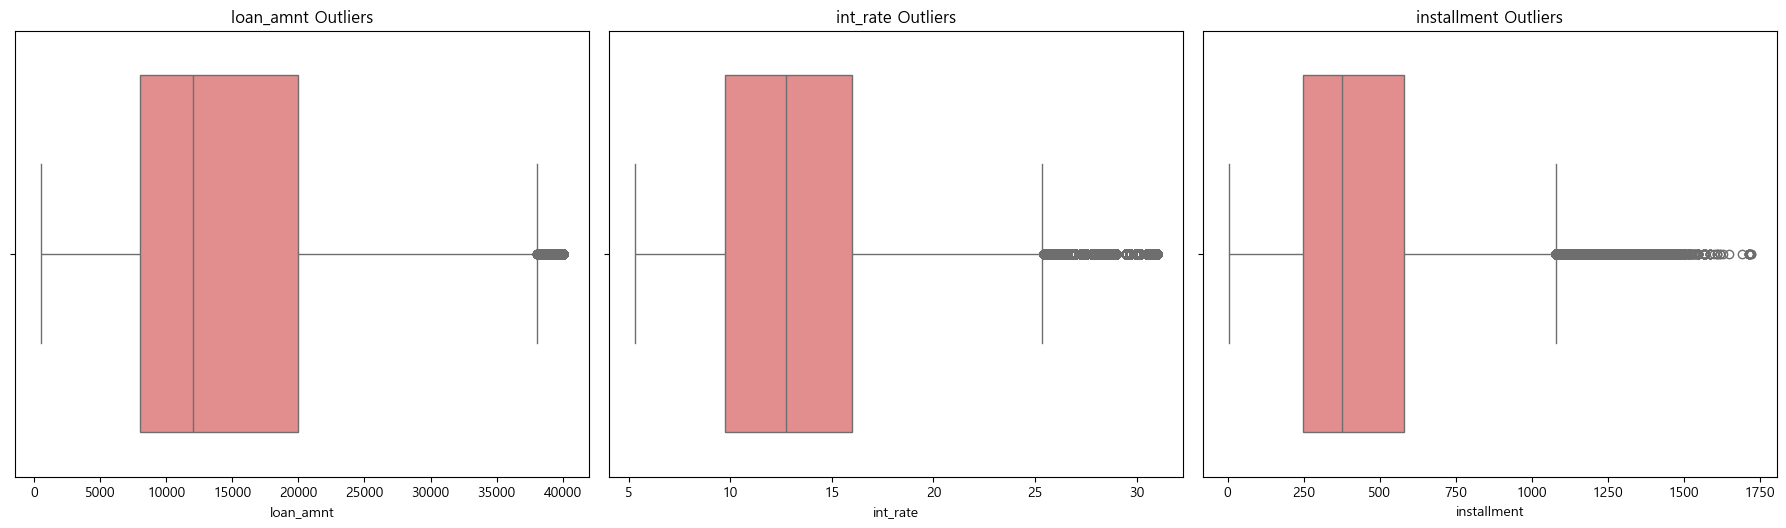

In [56]:
plt.figure(figsize=(18, 10))

for i, col in enumerate(num_cols):
    # 박스플롯 (이상치 확인)
    plt.subplot(2, 3, i+4)
    sns.boxplot(x=df4[col], color='lightcoral')
    plt.title(f'{col} Outliers')

plt.tight_layout()
plt.show()

In [57]:
print("\n--- [2] IQR 기준 이상치 탐지 ---")
for col in num_cols:
    Q1 = df4[col].quantile(0.25)
    Q3 = df4[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df4[(df4[col] < lower_bound) | (df4[col] > upper_bound)]
    print(f"{col}: 이상치 개수 {len(outliers)}개 (전체의 {len(outliers)/len(df4)*100:.2f}%)")


--- [2] IQR 기준 이상치 탐지 ---
loan_amnt: 이상치 개수 7154개 (전체의 0.53%)
int_rate: 이상치 개수 24977개 (전체의 1.85%)
installment: 이상치 개수 42189개 (전체의 3.13%)


In [58]:
Q1 = df4['installment'].quantile(0.25)
Q3 = df4['installment'].quantile(0.75)
IQR = Q3 - Q1

# 2. 이상치 경계값 설정 (상한선)
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

# 3. 이상치 데이터만 필터링
outliers_df = df4[(df4['installment'] > upper_bound) | (df4['installment'] < lower_bound)]

# 4. 결과 확인
print(f"전체 데이터 개수: {len(df4)}")
print(f"이상치 데이터 개수: {len(outliers_df)}")
print(f"이상치 경계값 (상한): ${upper_bound:.2f}")

# 상위 10개 행 확인 (주요 지표와 함께 보기)
display_cols = ['loan_amnt', 'installment', 'int_rate', 'grade', 'term', 'loan_status']
print("\n--- [installment 이상치 샘플] ---")
print(outliers_df[display_cols].head(10))

# 이상치 데이터의 기초 통계량 확인
print("\n--- [이상치 그룹의 통계량] ---")
print(outliers_df[display_cols].describe())

전체 데이터 개수: 1348059
이상치 데이터 개수: 42189
이상치 경계값 (상한): $1078.12

--- [installment 이상치 샘플] ---
     loan_amnt  installment  int_rate grade        term loan_status
103    33600.0      1096.53     10.78     B   36 months  Fully Paid
137    35000.0      1186.72     13.44     C   36 months  Fully Paid
155    35000.0      1104.71      8.49     B   36 months  Fully Paid
161    35000.0      1115.77      9.17     B   36 months  Fully Paid
182    35000.0      1196.05     13.99     C   36 months  Fully Paid
188    35000.0      1196.05     13.99     C   36 months  Fully Paid
233    35000.0      1196.05     13.99     C   36 months  Fully Paid
306    35000.0      1196.05     13.99     C   36 months  Fully Paid
329    35000.0      1177.27     12.88     C   36 months  Fully Paid
340    34000.0      1109.58     10.78     B   36 months  Fully Paid

--- [이상치 그룹의 통계량] ---
          loan_amnt   installment      int_rate
count  42189.000000  42189.000000  42189.000000
mean   34868.518453   1190.888251     14.60

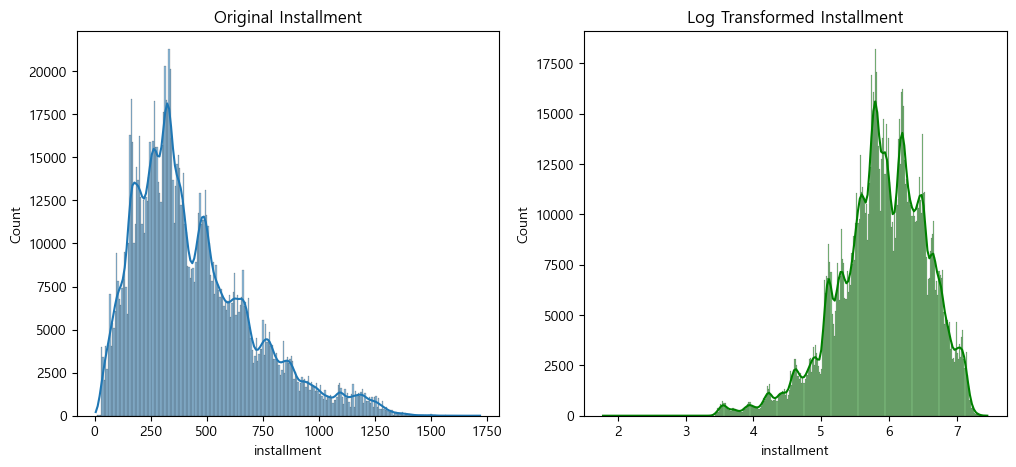

In [59]:
# 변환 전후 비교 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df4['installment'], kde=True)
plt.title('Original Installment')

plt.subplot(1, 2, 2)
# 로그 변환 적용 (log1p는 log(1+x)로 0값 에러 방지)
sns.histplot(np.log1p(df4['installment']), kde=True, color='green')
plt.title('Log Transformed Installment')

plt.show()

--- [1] 범주형 변수 기초 진단 ---
term       | 결측치:      0개 ( 0.00%) | 고유값:   2개
grade      | 결측치:      0개 ( 0.00%) | 고유값:   7개
sub_grade  | 결측치:      0개 ( 0.00%) | 고유값:  35개
purpose    | 결측치:      0개 ( 0.00%) | 고유값:  14개


C:\Users\gywns\AppData\Local\Temp\ipykernel_13716\1819971861.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df4[col], order=order, palette='viridis')
C:\Users\gywns\AppData\Local\Temp\ipykernel_13716\1819971861.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df4[col], order=order, palette='viridis')
C:\Users\gywns\AppData\Local\Temp\ipykernel_13716\1819971861.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df4[col], order=order, palette='viridis')
C:\Users\gywns\AppData\Local\Temp\ipykernel_13716\1819971861.py:19:

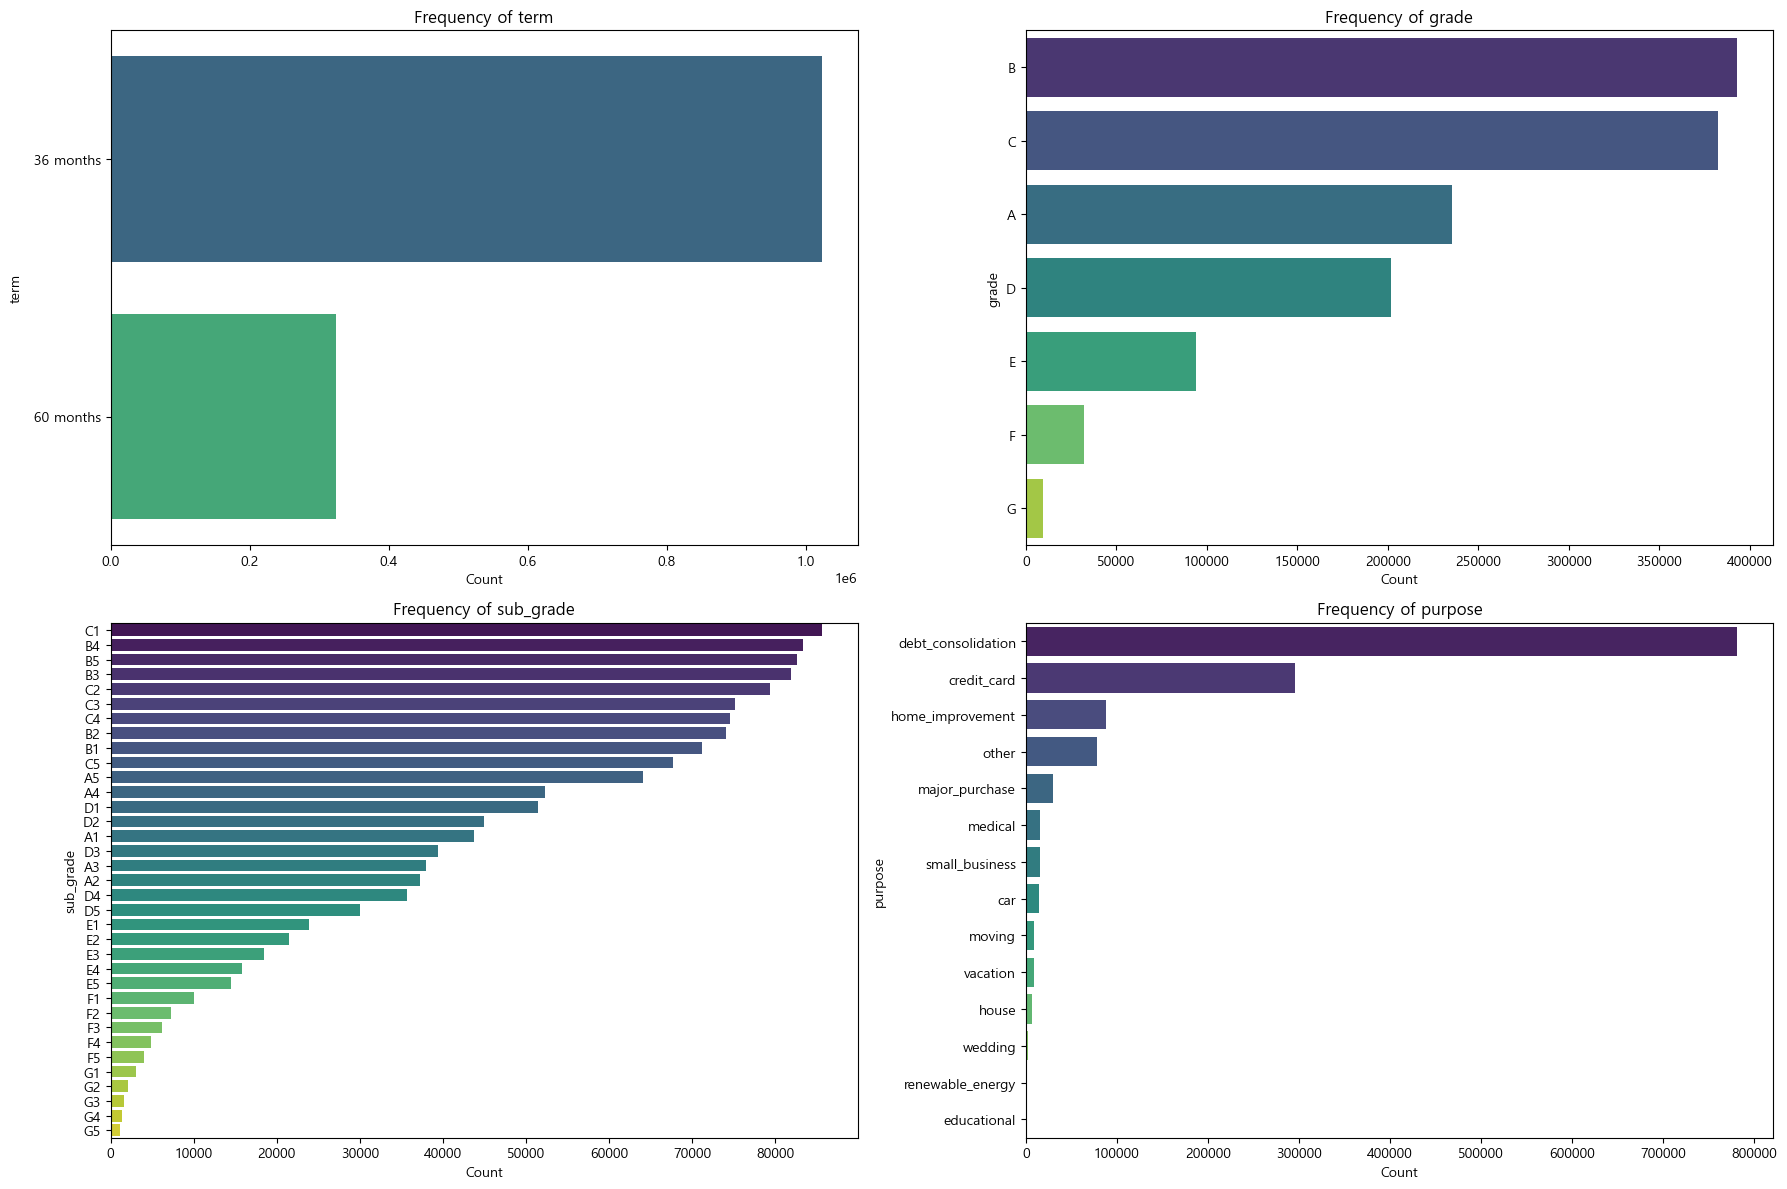

In [60]:
# 범주형 변수 확인 : term, grade, sub_grade, purpose
cat_cols = ['term', 'grade', 'sub_grade', 'purpose']

# 1. 결측치 및 고유값 개수 확인
print("--- [1] 범주형 변수 기초 진단 ---")
for col in cat_cols:
    null_count = df4[col].isnull().sum()
    null_rate = (null_count / len(df4)) * 100
    unique_count = df4[col].nunique()
    print(f"{col:10} | 결측치: {null_count:6}개 ({null_rate:5.2f}%) | 고유값: {unique_count:3}개")

# 2. 범주별 빈도 시각화 (이상치/희소 범주 탐지)
plt.figure(figsize=(18, 12))

for i, col in enumerate(cat_cols):
    plt.subplot(2, 2, i+1)
    # 빈도수 상위 순서대로 정렬하여 시각화
    order = df4[col].value_counts().index
    sns.countplot(y=df4[col], order=order, palette='viridis')
    plt.title(f'Frequency of {col}')
    plt.xlabel('Count')

plt.tight_layout()
plt.show()

In [61]:
display(df4['term'].value_counts())
display(df4['term'].isnull().sum())

term
36 months    1023181
60 months     324878
Name: count, dtype: int64

np.int64(0)

In [62]:
display(df4['grade'].value_counts())
display(df4['grade'].isnull().sum())

grade
B    393095
C    382315
A    235188
D    201644
E     94186
F     32305
G      9326
Name: count, dtype: int64

np.int64(0)

In [63]:
display(df4['sub_grade'].value_counts().head(10))
display(df4['sub_grade'].isnull().sum())

sub_grade
C1    85616
B4    83275
B5    82636
B3    81900
C2    79356
C3    75127
C4    74553
B2    74079
B1    71205
C5    67663
Name: count, dtype: int64

np.int64(0)

In [64]:
display(df4['purpose'].value_counts())
display(df4['purpose'].isnull().sum())

purpose
debt_consolidation    781421
credit_card           295619
home_improvement       87718
other                  78299
major_purchase         29548
medical                15612
small_business         15577
car                    14649
moving                  9526
vacation                9084
house                   7297
wedding                 2350
renewable_energy         936
educational              423
Name: count, dtype: int64

np.int64(0)

sub_grade와 int_rate의 상관계수: 0.9755


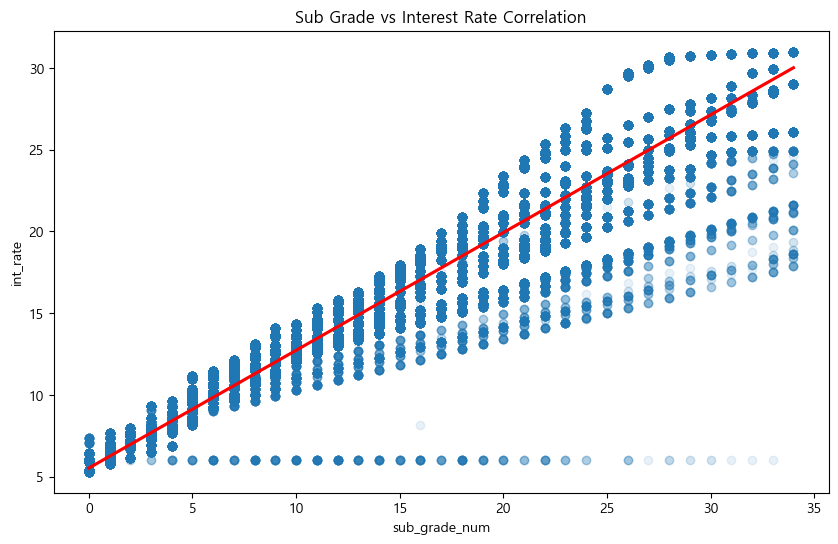

In [65]:
sub_grade_list = sorted(df4['sub_grade'].unique())
sub_grade_map = {val: i for i, val in enumerate(sub_grade_list)}

df4['sub_grade_num'] = df4['sub_grade'].map(sub_grade_map)

correlation = df4['sub_grade_num'].corr(df4['int_rate'])
print(f"sub_grade와 int_rate의 상관계수: {correlation:.4f}")

# 시각화로 확인
plt.figure(figsize=(10, 6))
sns.regplot(x='sub_grade_num', y='int_rate', data=df4, scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.title('Sub Grade vs Interest Rate Correlation')
plt.show()

--- [1] 결측치 및 요약 통계 ---
               count  missing_count  missing_rate (%)       mean   50%    max
total_acc  1348030.0             29               0.0  24.976081  23.0  176.0
open_acc   1348030.0             29               0.0  11.590455  11.0   90.0
pub_rec    1348030.0             29               0.0   0.215048   0.0   86.0


C:\Users\gywns\AppData\Local\Temp\ipykernel_13716\1465409783.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df4[col], palette='Set2')
C:\Users\gywns\AppData\Local\Temp\ipykernel_13716\1465409783.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df4[col], palette='Set2')
C:\Users\gywns\AppData\Local\Temp\ipykernel_13716\1465409783.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df4[col], palette='Set2')


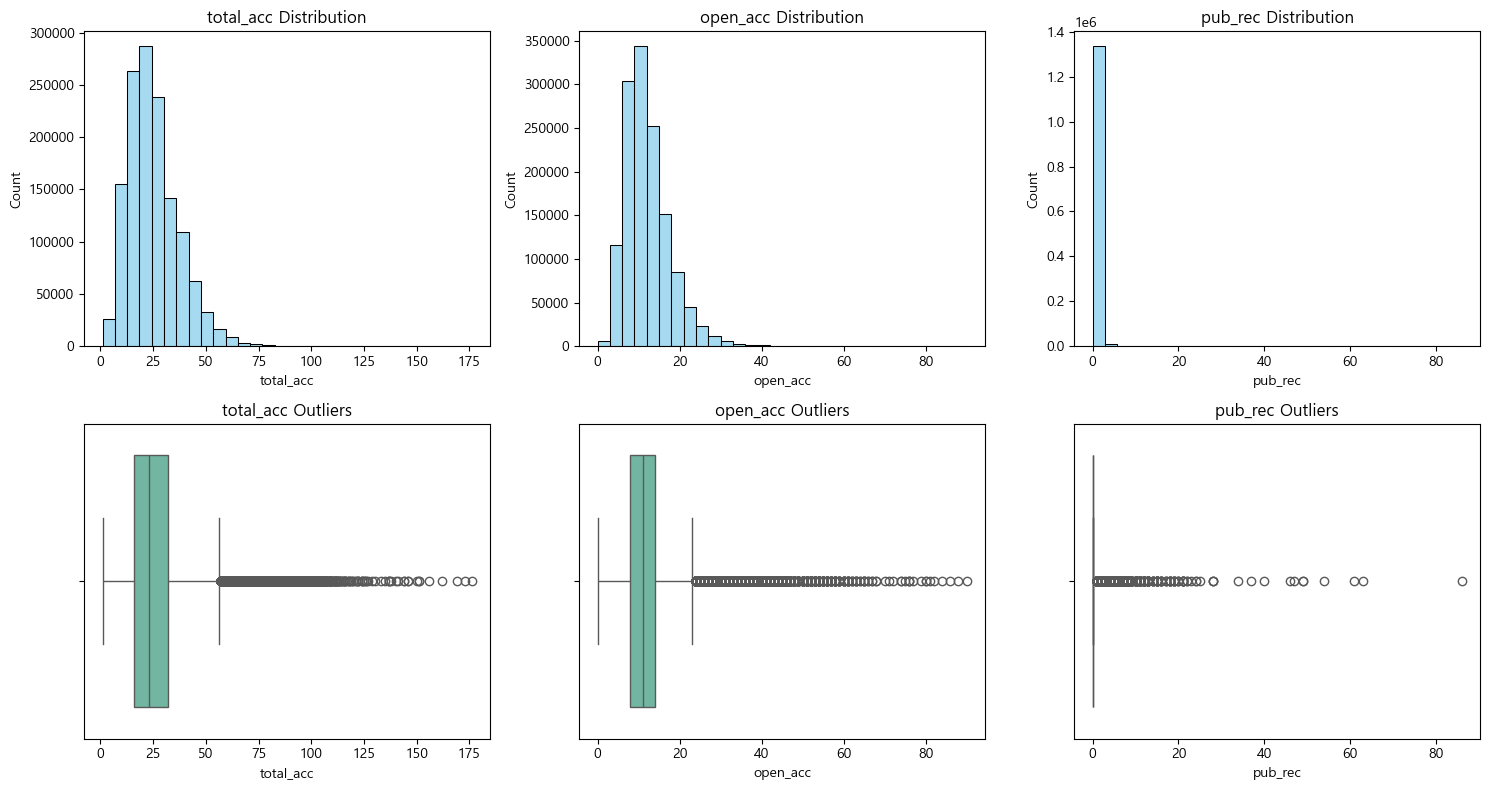


--- [2] IQR 기준 이상치 탐지 ---
total_acc: 상한선 56.0 초과 데이터 22674개 (1.68%)
open_acc: 상한선 23.0 초과 데이터 46165개 (3.42%)
pub_rec: 상한선 0.0 초과 데이터 228140개 (16.92%)


In [66]:
num_cols = ['total_acc', 'open_acc', 'pub_rec']

# 1. 결측치 및 기초 통계량 확인
print("--- [1] 결측치 및 요약 통계 ---")
stats = df4[num_cols].describe().T
stats['missing_count'] = df4[num_cols].isnull().sum()
stats['missing_rate (%)'] = (df4[num_cols].isnull().mean() * 100).round(2)
print(stats[['count', 'missing_count', 'missing_rate (%)', 'mean', '50%', 'max']])

# 2. 시각화 (히스토그램 & 박스플롯)
plt.figure(figsize=(15, 8))

for i, col in enumerate(num_cols):
    # 히스토그램: 데이터의 전반적인 분포 확인
    plt.subplot(2, 3, i+1)
    sns.histplot(df4[col].dropna(), kde=False, bins=30, color='skyblue')
    plt.title(f'{col} Distribution')
    
    # 박스플롯: 이상치(점) 확인
    plt.subplot(2, 3, i+4)
    sns.boxplot(x=df4[col], palette='Set2')
    plt.title(f'{col} Outliers')

plt.tight_layout()
plt.show()

# 3. IQR 기반 이상치 개수 계산
print("\n--- [2] IQR 기준 이상치 탐지 ---")
for col in num_cols:
    Q1 = df4[col].quantile(0.25)
    Q3 = df4[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df4[df4[col] > upper_bound]
    print(f"{col}: 상한선 {upper_bound:.1f} 초과 데이터 {len(outliers)}개 ({len(outliers)/len(df4)*100:.2f}%)")

--- [1] 범주형/날짜형 기초 진단 ---
initial_list_status  | 결측치:      0개 | 고유값:   2개
application_type     | 결측치:      0개 | 고유값:   2개
addr_state           | 결측치:      0개 | 고유값:  51개
earliest_cr_line     | 결측치:     29개 | 고유값: 739개


C:\Users\gywns\AppData\Local\Temp\ipykernel_13716\1008214085.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df4[col], order=order, palette='viridis')
C:\Users\gywns\AppData\Local\Temp\ipykernel_13716\1008214085.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df4[col], order=order, palette='viridis')
C:\Users\gywns\AppData\Local\Temp\ipykernel_13716\1008214085.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df4[col], order=order, palette='viridis')


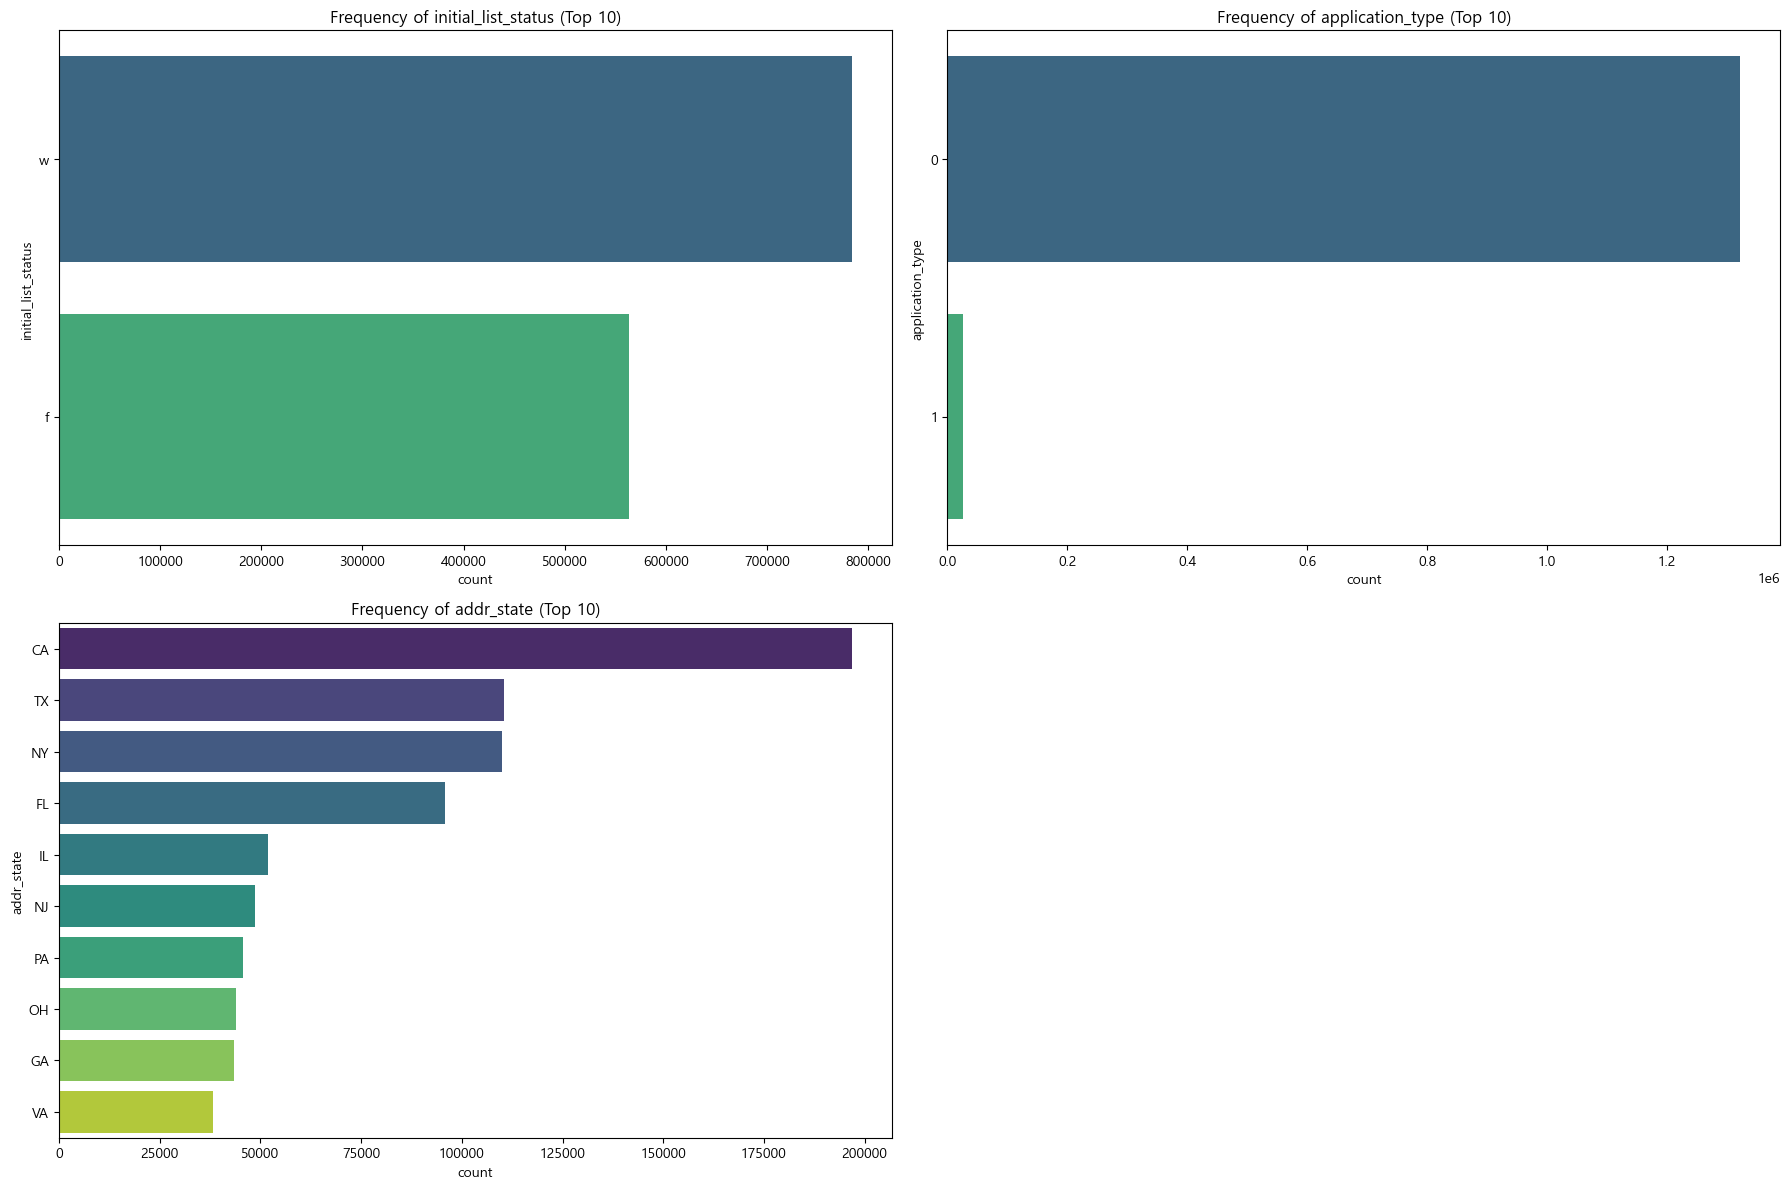


--- [2] 날짜 데이터 샘플 ---
0    Aug-2003
1    Dec-1999
2    Aug-2000
4    Jun-1998
5    Oct-1987
Name: earliest_cr_line, dtype: str


In [67]:
# 진단할 컬럼 리스트
cat_cols = ['initial_list_status', 'application_type', 'addr_state']
date_col = 'earliest_cr_line'

# 1. 결측치 및 고유값 개수 확인
print("--- [1] 범주형/날짜형 기초 진단 ---")
for col in cat_cols + [date_col]:
    null_count = df4[col].isnull().sum()
    unique_count = df4[col].nunique()
    print(f"{col:20} | 결측치: {null_count:6}개 | 고유값: {unique_count:3}개")

# 2. 범주별 빈도 시각화
plt.figure(figsize=(18, 12))

for i, col in enumerate(cat_cols):
    plt.subplot(2, 2, i+1)
    # 데이터가 많은 순서대로 상위 10개만 표시 (addr_state 고려)
    order = df4[col].value_counts().iloc[:10].index
    sns.countplot(y=df4[col], order=order, palette='viridis')
    plt.title(f'Frequency of {col} (Top 10)')

plt.tight_layout()
plt.show()

# 3. 날짜 데이터(earliest_cr_line) 샘플 확인
print("\n--- [2] 날짜 데이터 샘플 ---")
print(df4[date_col].head())

In [70]:
df4[df4['pub_rec'].isna()][['total_acc', 'open_acc', 'earliest_cr_line', 'pub_rec']]

,total_acc,open_acc,earliest_cr_line,pub_rec
1654329,NaN,NaN,NaN,NaN
1654330,NaN,NaN,NaN,NaN
1654339,NaN,NaN,NaN,NaN
1654352,NaN,NaN,NaN,NaN
1654360,NaN,NaN,NaN,NaN
1654363,NaN,NaN,NaN,NaN
1654374,NaN,NaN,NaN,NaN
1654389,NaN,NaN,NaN,NaN
1654394,NaN,NaN,NaN,NaN
1654395,NaN,NaN,NaN,NaN
